<a href="https://colab.research.google.com/github/himanshu-js/Machine_Learning/blob/main/Supervised%20Learning/Weather_Forecast_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of Logistic Regression Using Python (Scikit - learn)

## Step 1: Import Libraries

In [104]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

## Step 2: Load the Dataset

In [105]:
df = pd.read_csv('/content/weather_forecast_data.csv')

In [106]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


## Step 3: Information About the Dataset

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [108]:
df.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [109]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind_Speed,0
Cloud_Cover,0
Pressure,0
Rain,0


## Step 4: Encode the Target Variable

In [110]:
df['Rain'].head()

,Rain
0,rain
1,no rain
2,no rain
3,rain
4,no rain


In [111]:
df['Rain'] = df['Rain'].map({'rain':1,'no rain':0})

In [112]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,1
1,27.879734,46.489704,5.952484,4.990053,992.614190,0
2,25.069084,83.072843,1.371992,14.855784,1007.231620,0
3,23.622080,74.367758,7.050551,67.255282,982.632013,1
4,20.591370,96.858822,4.643921,47.676444,980.825142,0


## Step 5: Separate Feature(x) and Target(y)


*   Feature :  Independent Variable
*   Target  :  Dependent Variable



In [113]:
X = df[['Temperature','Humidity','Wind_Speed','Cloud_Cover','Pressure']]
y = df['Rain']

In [114]:
X.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
0,23.720338,89.592641,7.335604,50.501694,1032.378759
1,27.879734,46.489704,5.952484,4.990053,992.614190
2,25.069084,83.072843,1.371992,14.855784,1007.231620
3,23.622080,74.367758,7.050551,67.255282,982.632013
4,20.591370,96.858822,4.643921,47.676444,980.825142


In [115]:
y.head()

,Rain
0,1
1,0
2,0
3,1
4,0


## Step 6: Split the Dataset

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Step 7: Feature Scaling
* In this dataset pressure is having higher values than the other features, so here we are going to use StandardScaler class of preprocessing module to ensure that the values are onto the same scale


In [117]:
# import class
from sklearn.preprocessing import StandardScaler

In [118]:
# object assignment
Scaler = StandardScaler()

In [119]:
# X_train data scale
X_train_scaled = Scaler.fit_transform(X_train)

In [120]:
# X_test data scale
X_test_scaled = Scaler.transform(X_test)

In [121]:
# Add the balanced flag here
model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

## Step 8: Create the Logistic Model

In [122]:
model = LogisticRegression()

## Step 9: Train the Model

In [123]:
model.fit(X_train_scaled,y_train)

LogisticRegression()

## 9.1 Make Predictions

In [124]:
predictions = model.predict(X_test_scaled)

In [125]:
print(predictions)

[0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 

## Step 10: Check Accuracy

*   Accuracy measures how often the model makes correct predictions overall.

* Gives a quick idea of overall correctness
* Works well when classes are balanced



In [126]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.932


## Step 11: Display the Confusion Matrix

A confusion matrix shows where the model is right and where it makes mistakes by comparing predicted labels with actual labels.

  * Shows exact error types, not just a score
  * Helps understand false positives vs false negatives

In [127]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[430  13]
 [ 21  36]]


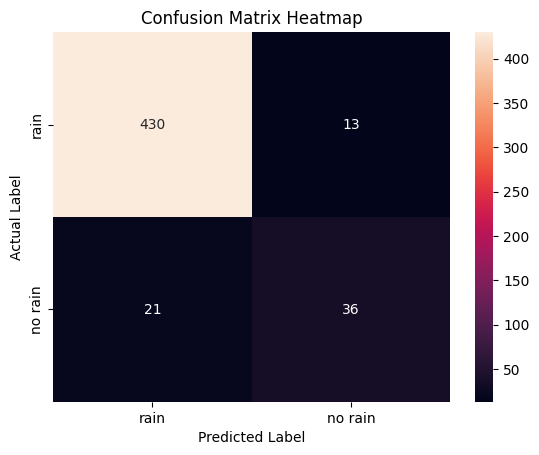

In [128]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['rain', 'no rain'],
    yticklabels=['rain', 'no rain']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### 11.1 Precision Score
Precision shows how many predicted positives are actually correct.

* Focuses on reducing false positives
* Important when wrong positives are costly
* Commonly used in spam and fraud detection

In [129]:
precision = precision_score(y_test, predictions)
f"Precision: {round(precision,2)}"

'Precision: 0.73'

### 11.2 Recall Score
Recall measures how many actual positives the model correctly identifies.

* Focuses on reducing false negatives
* Important when missing positives is risky

In [130]:
recall = recall_score(y_test, predictions)
f"Recall: {round(recall,2)}"

'Recall: 0.63'

### 11.3 F1 Score
F1 score balances precision and recall into a single metric.

* Useful when data is imbalanced
* Penalizes extreme precision or recall values
* Preferred when both false positives and false negatives matter

In [131]:
f1 = f1_score(y_test, predictions)
f"f1 score: {round(f1,2)}"

'f1 score: 0.68'

## Step 12: Predict New Data

In [132]:
weather_new = {
    'Temperature': [32.564],
    'Humidity': [12.987],
    'Wind_Speed': [44.897],
    'Cloud_Cover': [22.709],
    'Pressure': [1031.786]
}

df_new = pd.DataFrame(weather_new)


df_new_scaled = Scaler.transform(df_new)

Prediction_new = model.predict(df_new_scaled)

print("Model Output:")

if prediction_new[0] == 1:
    print("Rain")
else:
    print("No Rain")

print(f"accuracy:{accuracy}")
print(f"Precision: {round(precision,2)}")
print(f"Recall: {round(recall,2)}")
print(f"f1_score: {round(f1,2)}")



Model Output:
No Rain
accuracy:0.932
Precision: 0.73
Recall: 0.63
f1_score: 0.68
